# Notebook for analysis

In [2]:
# run the import and install packages.py file 
%run install_packages.py

MIRSI Simulations - Package Dependency Checker

Checking for required packages...
✓ numpy is already installed
✓ astropy is already installed
✓ matplotlib is already installed
✓ photutils is already installed
✓ scipy is already installed

✓ All required packages are already installed!

Setup complete! You can now run the MIRSI simulations.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry 


## DATA FROM 02-030-26

### Zenith

Processing 1500 FITS files from ./data/260203/zenith_dark
Loaded 1500 FITS files from ./data/260203/zenith_dark
Processing 1500 FITS files from ./data/260203/zenith_sky_1
Loaded 1500 FITS files from ./data/260203/zenith_sky_1
Processing 1500 FITS files from ./data/260203/zenith_sky_2
Loaded 1500 FITS files from ./data/260203/zenith_sky_2
Processing 1500 FITS files from ./data/260203/zenith_sky_3
Loaded 1500 FITS files from ./data/260203/zenith_sky_3


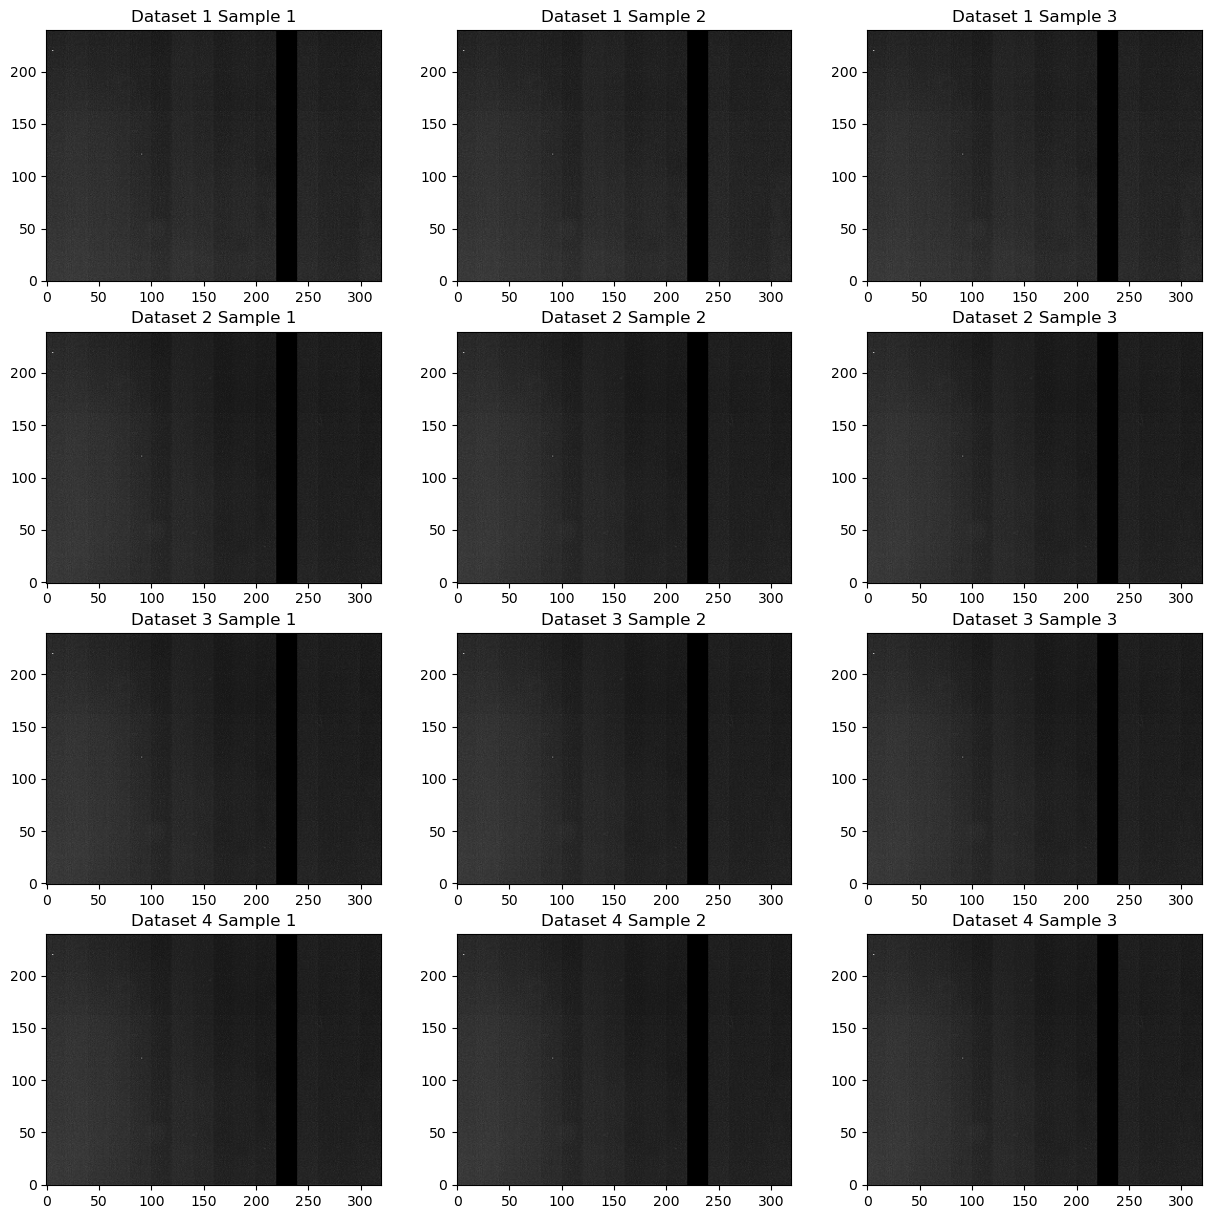

In [12]:
# Read in the data from the fits file 
from test_analysis import read_in_fits
zenith_dark_data = read_in_fits('./data/260203/zenith_dark')
zenith_sky_1_data = read_in_fits('./data/260203/zenith_sky_1')
zenith_sky_2_data = read_in_fits('./data/260203/zenith_sky_2')
zenith_sky_3_data = read_in_fits('./data/260203/zenith_sky_3')
# display three random images from each to make sure it loaded in correctly

list = [zenith_dark_data, zenith_sky_1_data, zenith_sky_2_data, zenith_sky_3_data]
test_fig, test_axs = plt.subplots(len(list), 3, figsize=(15,15))
for i, data in enumerate(list):
    for j in range(3):  # 3 samples per dataset
        test_axs[i, j].imshow(data[np.random.randint(0, data.shape[0])], cmap='gray', origin='lower')
        test_axs[i, j].set_title(f'Dataset {i+1} Sample {j+1}')
plt.show()

Perform aperture photometry in the selected region

In [13]:
from test_analysis import preliminary_analysis
region = (30,80,15)  # Example region (y, x, radius)
TRIM_FRAMES = (199, -1)

# Load another region 
region_2 = (150, 50, 15)

In [14]:
import numpy as np
from photutils.aperture import CircularAperture, CircularAnnulus

def extract_sky_timeseries(exposures, region, trim=None, annulus=None, statistic="mean"):
    """
    Build a 1D time series x[t] = sky level estimator from a fixed aperture (and optional annulus).

    Parameters
    ----------
    exposures : (n, H, W) ndarray
    region : (y, x, r)
        aperture center and radius in pixels
    trim : (i0, i1) or None
        slice frames: exposures[i0:i1]
    annulus : (r_in, r_out) or None
        if provided, compute annulus background and subtract it from aperture mean/sum
    statistic : {'mean','median','sum'}
        how to summarize pixels inside the aperture

    Returns
    -------
    out : dict with keys:
        'x_ap' : aperture statistic time series (background-subtracted if annulus given)
        'x_ann' : annulus statistic time series (if annulus given)
        'n_pix_ap', 'n_pix_ann'
    """
    if trim is not None:
        exposures = exposures[trim[0]:trim[1]]

    y, x, r = region
    pos = (x, y)

    ap = CircularAperture(pos, r=r)#
    ap_mask = ap.to_mask(method="center")
    # Fix: to_mask() returns a single mask, not a list - remove [0]
    ap_mask = ap_mask.to_image(exposures.shape[1:]).astype(bool)
    n_pix_ap = ap_mask.sum()

    if annulus is not None:
        r_in, r_out = annulus
        an = CircularAnnulus(pos, r_in=r_in, r_out=r_out)
        an_mask = an.to_mask(method="center")
        # Fix: same here - remove [0]
        an_mask = an_mask.to_image(exposures.shape[1:]).astype(bool)
        n_pix_ann = an_mask.sum()
    else:
        an_mask = None
        n_pix_ann = 0

    x_ap = np.empty(exposures.shape[0], dtype=float)
    x_ann = np.empty(exposures.shape[0], dtype=float) if an_mask is not None else None

    for i, frame in enumerate(exposures):
        ap_vals = frame[ap_mask]

        if statistic == "mean":
            ap_stat = np.mean(ap_vals)
        elif statistic == "median":
            ap_stat = np.median(ap_vals)
        elif statistic == "sum":
            ap_stat = np.sum(ap_vals)
        else:
            raise ValueError("statistic must be 'mean', 'median', or 'sum'")

        if an_mask is not None:
            ann_vals = frame[an_mask]
            # robust background: median is usually best
            ann_stat = np.median(ann_vals)
            x_ann[i] = ann_stat

            # subtract background in consistent units:
            # if 'sum', subtract (background * n_pix_ap); if mean/median, subtract background directly
            if statistic == "sum":
                ap_stat = ap_stat - ann_stat * n_pix_ap
            else:
                ap_stat = ap_stat - ann_stat

        x_ap[i] = ap_stat

    out = {"x_ap": x_ap, "n_pix_ap": n_pix_ap}
    if x_ann is not None:
        out.update({"x_ann": x_ann, "n_pix_ann": n_pix_ann})
    return out


In [15]:
def variance_vs_frequency_series(x, coadds_list, frame_dt_s, method, ddof=1):
    """
    For each coadds, average x into blocks and compute Var(block_means).
    """
    out = {"coadds": [], "f_eff_hz": [], "n_blocks": [], "var": []}

    for n in coadds_list:
        Ntrim = (len(x) // n) * n
        if Ntrim < 2*n:
            continue
        if method == "mean":
            xb = x[:Ntrim].reshape(-1, n).mean(axis=1)   # mean keeps units consistent
        if method  == "sum":
            xb = x[:Ntrim].reshape(-1, n).sum(axis=1)   # more physical for total flux
        out["coadds"].append(n)
        out["f_eff_hz"].append(1.0 / (frame_dt_s * n))
        out["n_blocks"].append(len(xb))
        out["var"].append(np.var(xb, ddof=ddof))

    return {k: np.array(v) for k, v in out.items()}


In [16]:
def variance_vs_frequency_chop_proxy(x, coadds_list, frame_dt_s, method, ddof=1):
    """
    For each coadds, compute block means then take successive differences and compute Var(diffs).

    
    """
    # Initialize output dictionary
    out = {"coadds": [], "f_eff_hz": [], "n_blocks": [], "var_diff": []}

    # Loop over each coadds value
    for n in coadds_list:
        # Trim x to a multiple of n
        Ntrim = (len(x) // n) * n
        if Ntrim < 3*n:   # need at least 3 blocks to get >=2 diffs
            continue
        # Groups n consecutive frames and computes their mean
        if method == "mean":
            xb = x[:Ntrim].reshape(-1, n).mean(axis=1)   # mean keeps units consistent
        if method  == "sum":
            xb = x[:Ntrim].reshape(-1, n).sum(axis=1)   # more physical for total flux

        # Computes successive differences (i.e. A - B subtraction)
        d = np.diff(xb)

        out["coadds"].append(n)
        out["f_eff_hz"].append(1.0 / (frame_dt_s * n))
        out["n_blocks"].append(len(xb))
        out["var_diff"].append(np.var(d, ddof=ddof))

    return {k: np.array(v) for k, v in out.items()}


In [17]:
zenith_dark = extract_sky_timeseries(zenith_dark_data, region, trim=None, annulus=None, statistic="mean")

zenith_sky_1 = extract_sky_timeseries(zenith_sky_1_data, region, trim=None, annulus=None, statistic="mean")

zenith_sky_2 = extract_sky_timeseries(zenith_sky_2_data, region, trim=None, annulus=None, statistic="mean")

zenith_sky_3 = extract_sky_timeseries(zenith_sky_3_data, region, trim=None, annulus=None, statistic="mean")


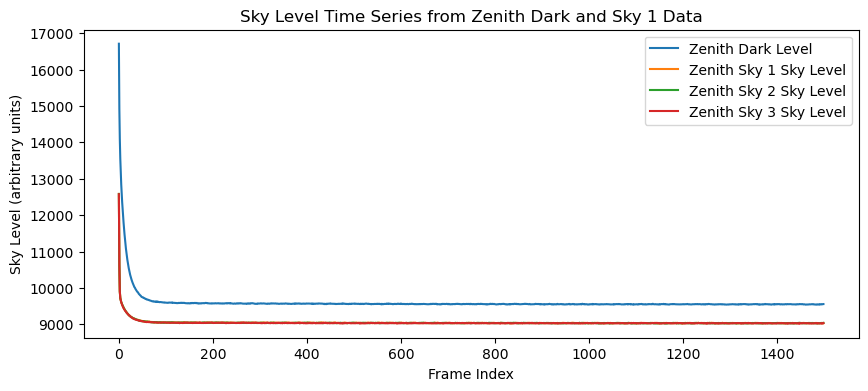

In [18]:
# First plot the non-trimmed time series
plt.figure(figsize=(10,4))
plt.plot(zenith_dark['x_ap'], label='Zenith Dark Level')
plt.plot(zenith_sky_1['x_ap'], label='Zenith Sky 1 Sky Level')
plt.plot(zenith_sky_2['x_ap'], label='Zenith Sky 2 Sky Level')
plt.plot(zenith_sky_3['x_ap'], label='Zenith Sky 3 Sky Level')
plt.xlabel('Frame Index')
plt.ylabel('Sky Level (arbitrary units)')
plt.title('Sky Level Time Series from Zenith Dark and Sky 1 Data')
plt.legend()
plt.show()

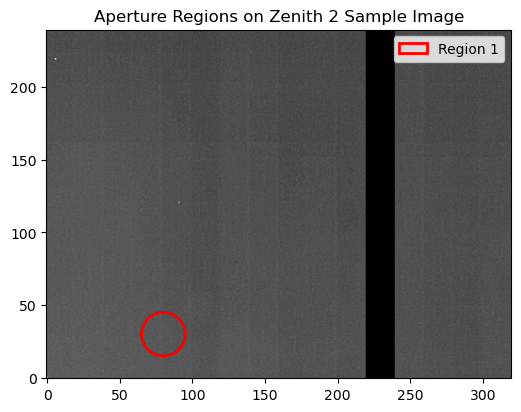

In [19]:
# Plot the two aperture regions on the image 
plt.figure(figsize=(6,6))
plt.imshow(zenith_dark_data[0], cmap='gray', origin='lower')
ap1 = CircularAperture((region[1], region[0]), r=region[2])
# ap2 = CircularAperture((region_2[1], region_2[0]), r=region_2[2])
ap1.plot(color='red', lw=2, label='Region 1')
#ap2.plot(color='blue', lw=2, label='Region 2')
plt.title('Aperture Regions on Zenith 2 Sample Image')
plt.legend()
plt.show()

the increase in counts as exposures increase is okay, you actually expect this if this is true dark current (detector warming up)

In [20]:
zenith_dark = extract_sky_timeseries(zenith_dark_data, region, trim=TRIM_FRAMES, annulus=None, statistic="sum")

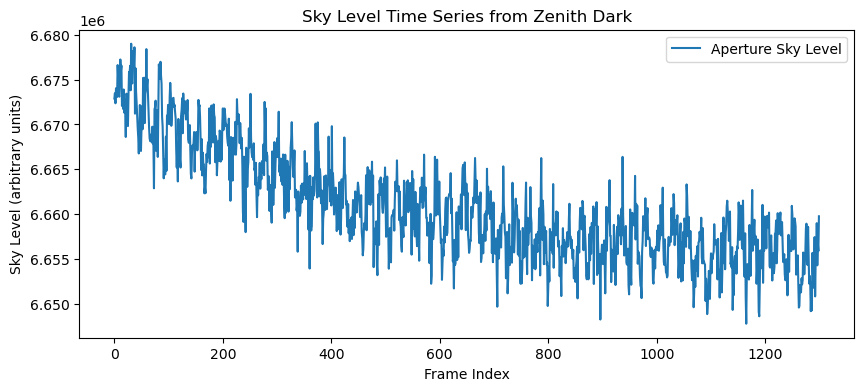

In [21]:
plt.figure(figsize=(10,4))
plt.plot(zenith_dark['x_ap'], label='Aperture Sky Level')
plt.xlabel('Frame Index')
plt.ylabel('Sky Level (arbitrary units)')
plt.title('Sky Level Time Series from Zenith Dark')
plt.legend()
plt.show()

In [22]:
zenith_sky_1 = extract_sky_timeseries(zenith_sky_1_data, region, trim=TRIM_FRAMES, annulus=None, statistic="sum")

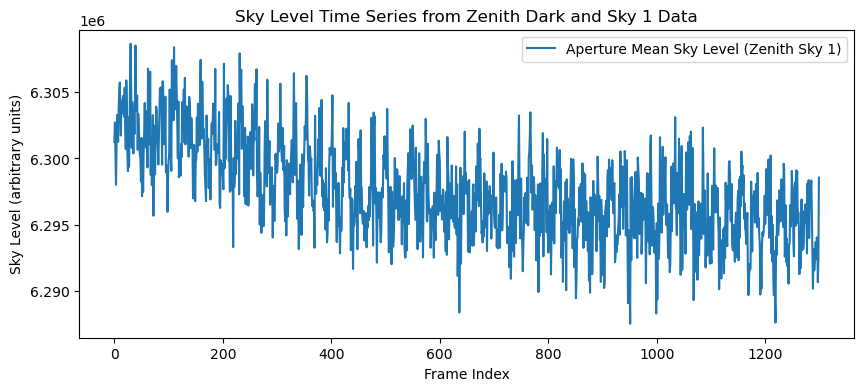

In [23]:
plt.figure(figsize=(10,4))
plt.plot(zenith_sky_1['x_ap'], label='Aperture Mean Sky Level (Zenith Sky 1)')
plt.xlabel('Frame Index')
plt.ylabel('Sky Level (arbitrary units)')
plt.title('Sky Level Time Series from Zenith Dark and Sky 1 Data')
plt.legend()
plt.show()

In [24]:
zenith_sky_2 = extract_sky_timeseries(zenith_sky_2_data, region, trim=TRIM_FRAMES, annulus=None, statistic="sum")

Text(0.5, 1.0, 'Sky Level Time Series Sky 2 Data')

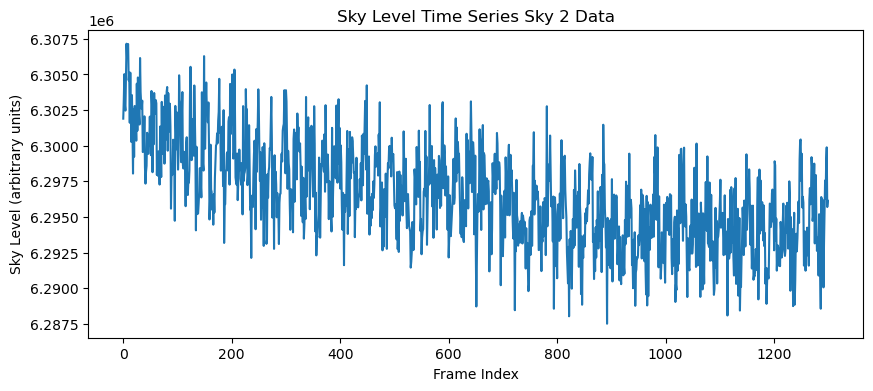

In [25]:
plt.figure(figsize=(10,4))
plt.plot(zenith_sky_2['x_ap'], label='Aperture Mean Sky Level (Zenith Sky 2)')
plt.xlabel('Frame Index')
plt.ylabel('Sky Level (arbitrary units)')
plt.title('Sky Level Time Series Sky 2 Data')

In [26]:
zenith_sky_3 = extract_sky_timeseries(zenith_sky_3_data, region, trim=TRIM_FRAMES, annulus=None, statistic="sum")

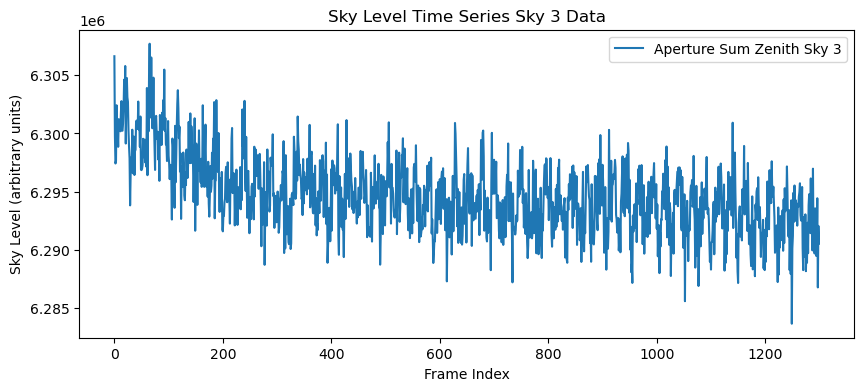

In [27]:
plt.figure(figsize=(10,4))
plt.plot(zenith_sky_3['x_ap'], label='Aperture Sum Zenith Sky 3')
plt.xlabel('Frame Index')
plt.ylabel('Sky Level (arbitrary units)')
plt.title('Sky Level Time Series Sky 3 Data')
plt.legend()
plt.show()

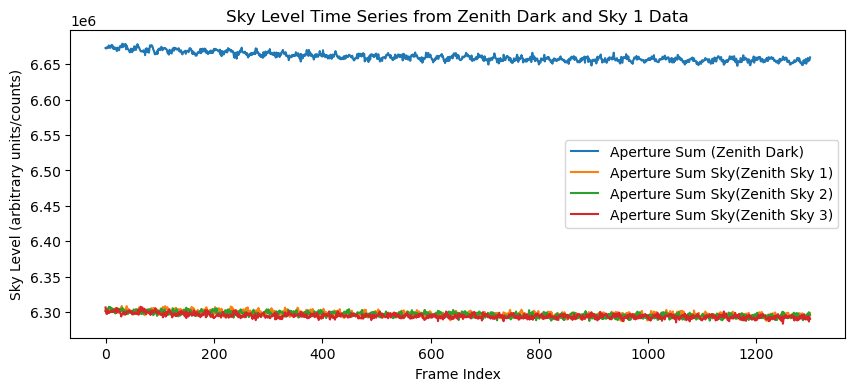

In [28]:
# Overplot the all together 
plt.figure(figsize=(10,4))
plt.plot(zenith_dark['x_ap'], label='Aperture Sum (Zenith Dark)')
plt.plot(zenith_sky_1['x_ap'], label='Aperture Sum Sky(Zenith Sky 1)')
plt.plot(zenith_sky_2['x_ap'], label='Aperture Sum Sky(Zenith Sky 2)')
plt.plot(zenith_sky_3['x_ap'], label='Aperture Sum Sky(Zenith Sky 3)')
plt.xlabel('Frame Index')
plt.ylabel('Sky Level (arbitrary units/counts)')
plt.title('Sky Level Time Series from Zenith Dark and Sky 1 Data')
plt.legend()
plt.show()

# Simulate Chopping and Nodding

In [29]:
# Make a list of integers for coadds 5 - 100
coadds_list = np.arange(5, 251)
#cadds_list = [6, 7, 8,9, 10,20,30, 40, 50, 60, 70, 80, 90, 100]

In [36]:
zenith_sky_chopped_1 = variance_vs_frequency_chop_proxy(zenith_sky_1['x_ap'], coadds_list, frame_dt_s=0.0103, method="sum")
zenith_sky_chopped_2 = variance_vs_frequency_chop_proxy(zenith_sky_2['x_ap'], coadds_list, frame_dt_s=0.0103, method="sum")
zenith_sky_chopped_3 = variance_vs_frequency_chop_proxy(zenith_sky_3['x_ap'], coadds_list, frame_dt_s=0.0103, method="sum")

zenith_sky_dark = variance_vs_frequency_chop_proxy(zenith_dark['x_ap'], coadds_list, frame_dt_s=0.0103, method="sum")

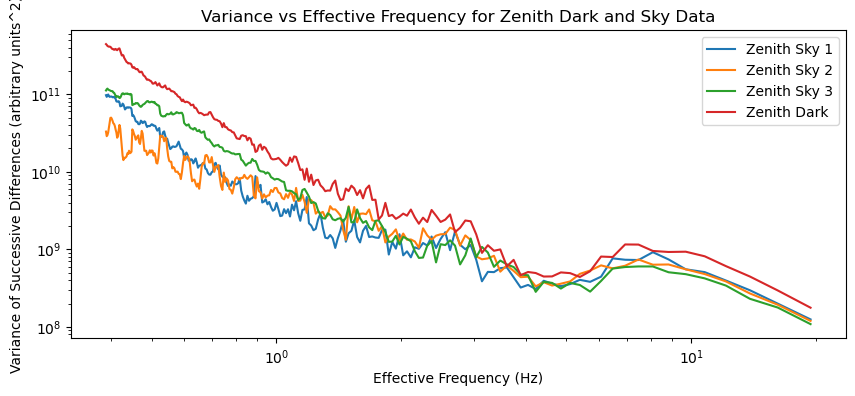

In [37]:
plt.figure(figsize=(10,4))
plt.plot(zenith_sky_chopped_1['f_eff_hz'], zenith_sky_chopped_1['var_diff'], label='Zenith Sky 1')
plt.plot(zenith_sky_chopped_2['f_eff_hz'], zenith_sky_chopped_2['var_diff'], label='Zenith Sky 2')
plt.plot(zenith_sky_chopped_3['f_eff_hz'], zenith_sky_chopped_3['var_diff'], label='Zenith Sky 3')
plt.plot(zenith_sky_dark['f_eff_hz'], zenith_sky_dark['var_diff'], label='Zenith Dark')
plt.xlabel('Effective Frequency (Hz)')
plt.ylabel('Variance of Successive Differences (arbitrary units^2)')
plt.title('Variance vs Effective Frequency for Zenith Dark and Sky Data')
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.show()

Clearly, the detector has some gain issues, so we can actually look at D/N instead replot in terms of DN per pixel per second

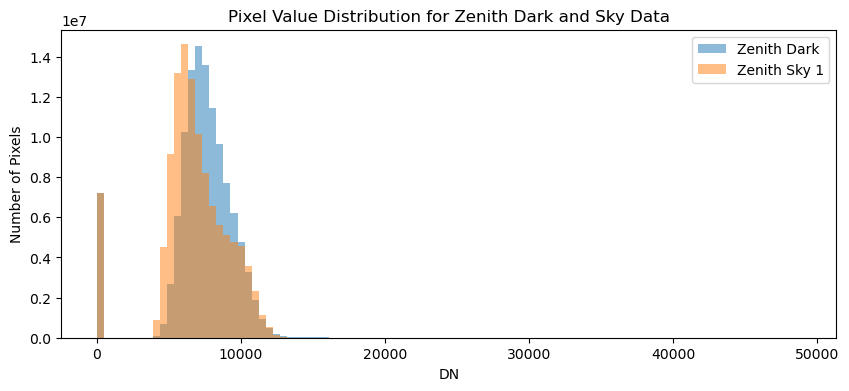

In [33]:
# Take the original image and make a histogram of all pixel values to see the distribution of pixel values in the image
plt.figure(figsize=(10,4))
plt.hist(zenith_dark_data.flatten(), bins=100, alpha=0.5, label='Zenith Dark')
plt.hist(zenith_sky_1_data.flatten(), bins=100, alpha=0.5, label='Zenith Sky 1')
# plt.hist(zenith_sky_2_data.flatten(), bins=100, alpha=0.5, label='Zenith Sky 2')
# plt.hist(zenith_sky_3_data.flatten(), bins=100, alpha=0.5, label='Zenith Sky 3')
plt.xlabel('DN')
plt.ylabel('Number of Pixels')
plt.title('Pixel Value Distribution for Zenith Dark and Sky Data')
plt.legend()
plt.show()

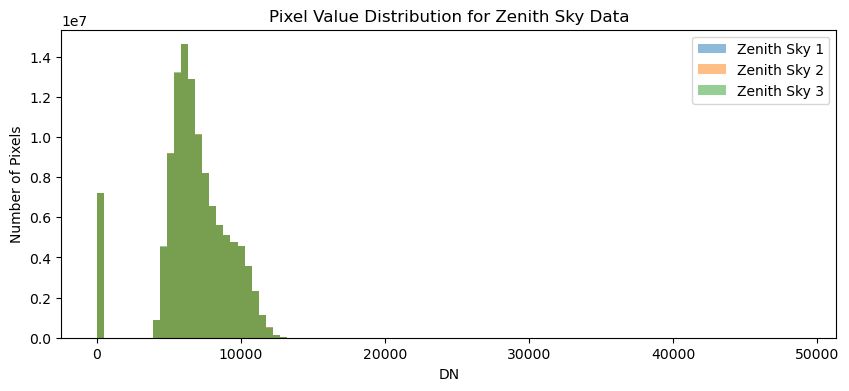

In [35]:
# Plot all the sky data frames
plt.figure(figsize=(10,4))
plt.hist(zenith_sky_1_data.flatten(), bins=100, alpha=0.5, label='Zenith Sky 1')
plt.hist(zenith_sky_2_data.flatten(), bins=100, alpha=0.5, label='Zenith Sky 2')
plt.hist(zenith_sky_3_data.flatten(), bins=100, alpha=0.5, label='Zenith Sky 3')
plt.xlabel('DN')
plt.ylabel('Number of Pixels')
plt.title('Pixel Value Distribution for Zenith Sky Data')   
plt.legend()
plt.show()

The itime for the array is 0.0103 seconds. So we want to find the DN/per pixel per second 

Median of Zenith Dark in counts/s: 721359.2233009709
Median of Zenith Sky 1 in counts/s: 645631.067961165


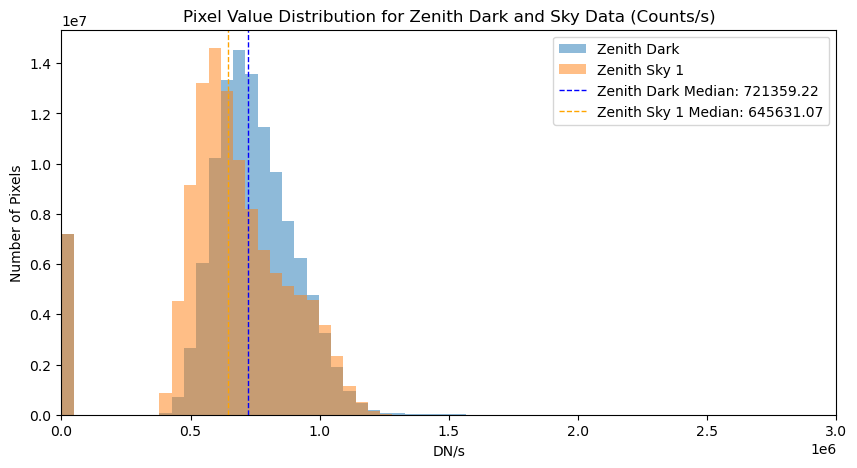

In [42]:
# Take all the values of the dark and the zenith sky one and scale by 1/0.0103 to convert to counts/s and then make a histogram of the pixel values to see the distribution of pixel values in the image in counts/s
plt.figure(figsize=(10,5))
plt.hist(zenith_dark_data.flatten() / 0.0103, bins=100, alpha=0.5, label='Zenith Dark')
plt.hist(zenith_sky_1_data.flatten() / 0.0103, bins=100, alpha=0.5, label='Zenith Sky 1')
plt.xlabel('DN/s')
plt.ylabel('Number of Pixels')
plt.title('Pixel Value Distribution for Zenith Dark and Sky Data (Counts/s)')
plt.legend()

# print the median of the dark and the zenith sky one in counts/s
print(f'Median of Zenith Dark in counts/s: {np.median(zenith_dark_data.flatten() / 0.0103)}')
print(f'Median of Zenith Sky 1 in counts/s: {np.median(zenith_sky_1_data.flatten() / 0.0103)}')

axvline_dark = np.median(zenith_dark_data.flatten() / 0.0103)
axvline_sky_1 = np.median(zenith_sky_1_data.flatten() / 0.0103)
plt.axvline(axvline_dark, color='blue', linestyle='dashed', linewidth=1, label=f'Zenith Dark Median: {axvline_dark:.2f}')
plt.axvline(axvline_sky_1, color='orange', linestyle='dashed', linewidth=1, label=f'Zenith Sky 1 Median: {axvline_sky_1:.2f}')
plt.xlim(0, 3e6)
plt.legend()    
plt.show()

Compare this to the expected counts you might expect to see given the sky T_sky = 250 K and the telescope at T_tel = 273 K

We use a modified version of the compute sky background rate code 

In [45]:
from sky_sim import compute_sky_background_rate_with_tel

sky_background_rate = compute_sky_background_rate_with_tel(
    wavelength=10e-6, 
    temperature_sky=250,      # Typical sky at 10 μm
    temperature_telescope=273, # Room temperature mirror
    emissivity_telescope=0.1   # Aluminum mirror
)

Sky background rate: 5.21e+08 photons/s/pixel
Telescope thermal emission rate: 2.83e+08 photons/s/pixel
Total background rate: 8.03e+08 photons/s/pixel
Telescope contribution: 35.2%


NameError: name 'z2_2' is not defined

<Figure size 1000x400 with 0 Axes>

In [ ]:
from scipy.ndimage import uniform_filter1d

First just try plotting the values and looking at the scatter we'll just bin the data and see


In [ ]:
#  

In [ ]:
# binned twice 
coadds_2 = uniform_filter1d(z2['x_ap'], size=2, mode='nearest')[::2]
coadds_3 = uniform_filter1d(z2['x_ap'], size=3, mode='nearest')[::3]
coadds_5 = uniform_filter1d(z2['x_ap'], size=5,
    mode='nearest')[::5]
coadds_10 = uniform_filter1d(z2['x_ap'], size=10,
    mode='nearest')[::10]
coadds_20 = uniform_filter1d(z2['x_ap'], size=20,
    mode='nearest')[::20]
coadds_50 = uniform_filter1d(z2['x_ap'], size=50,
    mode='nearest')[::50]   
coadds_100 = uniform_filter1d(z2['x_ap'], size=100,
    mode='nearest')[::100]
caoadds_200 = uniform_filter1d(z2['x_ap'], size=200,
    mode='nearest')[::200]

In [ ]:
#  overplot the binned data
plt.figure(figsize=(20, 6))
plt.plot(z2['x_ap'], label='Aperture Mean Sky Level', alpha = 0.3)
plt.plot(z3['x_ap'], label='Aperture Mean Sky Level (Zenith 3)', alpha = 0.3)
plt.scatter(range(0, len(z2['x_ap']), 2), coadds_2, label='Binned (2 frames) Sky Level', marker='.')
plt.scatter(range(0, len(z2['x_ap']), 3), coadds_3, label='Binned (3 frames) Sky Level', marker='.')
plt.scatter(range(0, len(z2['x_ap']), 5), coadds_5, label='Binned (5 frames) Sky Level', marker='.')
plt.scatter(range(0, len(z2['x_ap']), 10), coadds_10, label='Binned (10 frames) Sky Level', marker='.')
plt.scatter(range(0, len(z2['x_ap']), 20), coadds_20, label='Binned (20 frames) Sky Level', marker='.')
plt.scatter(range(0, len(z2['x_ap']), 50), coadds_50, label='Binned (50 frames) Sky Level', marker='.')
plt.scatter(range(0, len(z2['x_ap']), 100), coadds_100, label='Binned (100 frames) Sky Level', marker='.')
plt.scatter(range(0, len(z2['x_ap']), 200), caoadds_200, label='Binned (200 frames) Sky Level', marker='.')

plt.xlabel('Frame Index')
plt.ylabel('Sky Level (arbitrary units)')
plt.title('Sky Level Time Series with Binned Data')
plt.legend()
plt.show()

In [ ]:
# plot and fill in the 1 sigma ranges for each binned series

plt.figure(figsize=(10, 6))
for label, (bmin, bmax) in binned_stats.items():
    plt.fill_betweenx([bmin, bmax], 0, len(z2['x_ap']), alpha=0.2, label=f'{label} range')      
plt.xlabel('Frame Index')
plt.ylabel('Sky Level (arbitrary units)')
plt.title('Range of Sky Levels for Each Binned Series')
plt.legend()
plt.show()

In [ ]:
# Make a list of integers for coadds 5 - 100
cadds_list = np.arange(5, 251)
#cadds_list = [6, 7, 8,9, 10,20,30, 40, 50, 60, 70, 80, 90, 100]

v2_series = variance_vs_frequency_series(
    z2['x_ap'], cadds_list, frame_dt_s=0.0113, method="mean")
v2_chop = variance_vs_frequency_chop_proxy(
    z2['x_ap'], cadds_list, frame_dt_s=0.0113, method="mean")
v3_series = variance_vs_frequency_series(
    z3['x_ap'], cadds_list, frame_dt_s=0.0113, method="mean")
v3_chop = variance_vs_frequency_chop_proxy(
    z3['x_ap'], cadds_list, frame_dt_s=0.0113, method="mean")

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(v2_series['f_eff_hz'], v2_series['var'],
         marker='o', label='Var Series')
plt.plot(v2_chop['f_eff_hz'], v2_chop['var_diff']/2,
         marker='s', label='Var Chop Proxy')
plt.plot(v3_series['f_eff_hz'], v3_series['var'],
         marker='o', label='Var Series (Zenith 3)')
plt.plot(v3_chop['f_eff_hz'], v3_chop['var_diff']/2,
         marker='s', label='Var Chop Proxy (Zenith 3)')
plt.xlabel('Effective Frame Rate (Hz)')
plt.ylabel(r"Chop–proxy sky variance [$({\rm counts})^2$]")

plt.title('Variance vs Effective Frame Rate')
plt.legend()
plt.show()

In [ ]:
# Zoom in on the plot 
plt.figure(figsize=(10,4))
plt.plot(v2_series['f_eff_hz'], v2_series['var'],
         marker='o', label='Var Series')
plt.plot(v2_chop['f_eff_hz'], v2_chop['var_diff']/2,
         marker='s', label='Var Chop Proxy')
plt.plot(v3_series['f_eff_hz'], v3_series['var'],
         marker='o', label='Var Series (Zenith 3)')
plt.plot(v3_chop['f_eff_hz'], v3_chop['var_diff']/2,
         marker='s', label='Var Chop Proxy (Zenith 3)')
plt.xlabel('Effective Frame Rate (Hz)')
plt.ylabel(r"Chop–proxy sky variance [$({\rm counts})^2$]")
#plt.xlim(0, 7)  # Zoom in on x-axis
plt.xscale('log')
plt.title('Variance vs Effective Frame Rate (Zoomed In)')
plt.legend()

This isn't conceptually that accurate though, since you'd expect that averaging more frames (resulting in lower effective frame rates). But try using the sum instead of the average 

In [ ]:
v2_series_summed = variance_vs_frequency_series(
    z2['x_ap'], cadds_list, frame_dt_s=0.0113, method="sum")
v2_chop_summed = variance_vs_frequency_chop_proxy(
    z2['x_ap'], cadds_list, frame_dt_s=0.0113, method="sum")
v3_series_summed = variance_vs_frequency_series(
    z3['x_ap'], cadds_list, frame_dt_s=0.0113, method="sum")
v3_chop_summed = variance_vs_frequency_chop_proxy(
    z3['x_ap'], cadds_list, frame_dt_s=0.0113, method="sum")


In [ ]:
plt.figure(figsize=(10,4))
# plt.plot(v2_series_summed['f_eff_hz'], v2_series_summed['var'],
#          marker='o', label='Var Series (Summed)')
plt.plot(v2_chop_summed['f_eff_hz'], v2_chop_summed['var_diff']/2,
         marker='s', label='Var Chop Proxy (Summed)')
# plt.plot(v3_series_summed['f_eff_hz'], v3_series_summed['var'],
#          marker='o', label='Var Series (Zenith 3, Summed)')
plt.plot(v3_chop_summed['f_eff_hz'], v3_chop_summed['var_diff']/2,
         marker='s', label='Var Chop Proxy (Zenith 3, Summed)')
plt.xlabel('Effective Frame Rate (Hz)')
plt.ylabel(r"Chop–proxy sky variance [$({\rm counts})^2$]")
plt.title('Variance vs Effective Frame Rate (Summed Method)')
plt.xscale('log')
plt.legend()

# Draw a line at the 3.716 hz value in the frame rate 
plt.axvline(x=3.716, color='r', linestyle='--', label='3.716 Hz Reference')
plt.show()

In [ ]:
# Replot this in log space 
plt.figure(figsize=(10,4))
# plt.plot(v2_series_summed['f_eff_hz'], v2_series_summed['var'],
#          marker='o', label='Var Series (Summed)')
plt.plot(v2_chop_summed['f_eff_hz'], v2_chop_summed['var_diff']/2,
         marker='s', label='Var Chop Proxy (Summed)')
# plt.plot(v3_series_summed['f_eff_hz'], v3_series_summed['var'],
#          marker='o', label='Var Series (Zenith 3, Summed)')
plt.plot(v3_chop_summed['f_eff_hz'], v3_chop_summed['var_diff']/2,
         marker='s', label='Var Chop Proxy (Zenith 3, Summed)')
plt.xlabel('Effective Frame Rate (Hz)')
plt.ylabel(r"Chop–proxy sky variance [$({\rm counts})^2$]")
plt.title('Variance vs Effective Frame Rate (Summed Method)')
plt.xscale('log')
plt.yscale('log')
plt.legend()

# Draw a line at the 3.716 hz value in the frame rate 
plt.axvline(x=3.716, color='r', linestyle='--', label='3.716 Hz Reference')
plt.show()

#### Take a look at the "long term" behavior 

In [ ]:
# Get a PSD of the time series
from scipy.signal import welch
f2, Pxx2 = welch(z2['x_ap'], fs=1/0.0113, nperseg=1024)

# Other time series 
f3, Pxx3 = welch(z3['x_ap'], fs=1/0.0113, nperseg=1024)
fig, ax = plt.subplots(figsize=(10,4))
ax.loglog(f2, Pxx2, label='Zenith 2')
ax.loglog(f3, Pxx3, label='Zenith 3')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power Spectral Density [counts$^2$/Hz]')
ax.set_title('Power Spectral Density of Sky Level Time Series')

# Find the maximum value 
max2_index = np.argmax(Pxx2)
max2_frequency = f2[max2_index]
max2_value = Pxx2[max2_index]

max3_index = np.argmax(Pxx3)
max3_frequency = f3[max3_index]
max3_value = Pxx3[max3_index]


plt.axvline(max2_frequency, color='r', linestyle='--', label=f'Zenith 2 Peak: {max2_frequency:.3f} Hz')
plt.axvline(max3_frequency, color='g', linestyle='--', label=f'Zenith 3 Peak: {max3_frequency:.3f} Hz')
plt.legend()
plt.show()

Look at the second aperture

In [ ]:
z2_2['x_ap']

In [ ]:
z2['x_ap']

In [ ]:
v2_2_chop = variance_vs_frequency_chop_proxy(
    z2_2['x_ap'], cadds_list, frame_dt_s=0.0113, method="sum")
v3_2_chop = variance_vs_frequency_chop_proxy(
    z3_2['x_ap'], cadds_list, frame_dt_s=0.0113, method="sum")

# Plot the result 
plt.figure(figsize=(10,4))
plt.plot(v2_2_chop['f_eff_hz'], v2_2_chop['var_diff']/2,
         marker='s', label='Var Chop Proxy (Region 2, Zenith 2, Summed)')
plt.plot(v3_2_chop['f_eff_hz'], v3_2_chop['var_diff']/2,
         marker='s', label='Var Chop Proxy (Region 2, Zenith 3, Summed)')
plt.xlabel('Effective Frame Rate (Hz)')
plt.ylabel(r"Chop–proxy sky variance [$({\rm counts})^2$]")
plt.title('Variance vs Effective Frame Rate (Summed Method) - Region 2')
plt.xscale('log')
plt.yscale('log')
plt.legend() 
plt.show()  

Neat, and what does the PSD look like

In [ ]:
f2_2, Pxx2_2 = welch(z2_2['x_ap'], fs=1/0.0113, nperseg=1024)
f3_2, Pxx3_2 = welch(z3_2['x_ap'], fs=1/0.0113, nperseg=1024)
fig, ax = plt.subplots(figsize=(10,4))
ax.loglog(f2_2, Pxx2_2, label='Zenith 2 - Region 2')
ax.loglog(f3_2, Pxx3_2, label='Zenith 3 - Region 2')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power Spectral Density [counts$^2$/Hz]')
ax.set_title('Power Spectral Density of Sky Level Time Series - Region 2')      

# Find the maximum value
max2_2_index = np.argmax(Pxx2_2)
max2_2_frequency = f2_2[max2_2_index]
max2_2_value = Pxx2_2[max2_2_index]

max3_2_index = np.argmax(Pxx3_2)
max3_2_frequency = f3_2[max3_2_index]
max3_2_value = Pxx3_2[max3_2_index]

plt.axvline(max2_2_frequency, color='r', linestyle='--', label=f'Zenith 2 Peak: {max2_2_frequency:.3f} Hz')
plt.axvline(max3_2_frequency, color='g', linestyle='--', label=f'Zenith 3 Peak: {max3_2_frequency:.3f} Hz')

plt.legend()
plt.show()

## Zenith Short Exposures 

Here we test the expsoures where we have "shortened exposure time". 
We may get more impacts from things like dark current, but still should be useful for trying to test out correlated sky. 

In [ ]:
# Import the data 
zenith_SE_data = read_in_fits('./data/251227/zenith_4_se')
z4_SE = extract_sky_timeseries(zenith_SE_data, region, trim=None, annulus=None, statistic="mean")


In [ ]:
# plot the time series
plt.figure(figsize=(10,4))
plt.plot(z4_SE['x_ap'], label='Aperture Mean Sky Level (Zenith 4 SE)')
plt.xlabel('Frame Index')
plt.ylabel('Sky Level (arbitrary units)')
plt.title('Sky Level Time Series from Zenith 4 SE Data')
plt.legend()
plt.show()

it looks like the "ramp down" happens faster in this series 


In [ ]:
# Reload int ghe datea taking from frame number ~400 to the end 
z4_SE_clipped = extract_sky_timeseries(zenith_SE_data, region, trim=(400, None), annulus=None, statistic="mean")

# pick new region (larger radius)
# should be double the previous area (sqrt 2 times the radius)
region2 = (30,80,30)

s4_SE_clipped_large = extract_sky_timeseries(zenith_SE_data, region2, trim=(400, None), annulus=None, statistic="mean")

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(z4_SE_clipped['x_ap'], label='Aperture Mean Sky Level (Zenith 4 SE Clipped)')
plt.plot(s4_SE_clipped_large['x_ap'], label='Aperture Mean Sky Level (Zenith 4 SE Clipped, Larger Aperture)')
plt.xlabel('Frame Index')
plt.ylabel('Sky Level (arbitrary units)')
plt.title('Sky Level Time Series from Zenith 4 SE Clipped Data')
plt.legend()
plt.show()

Still a significant downturn in counts...

In [ ]:
# increase the coadds list for this data set
cadds_list = np.arange(10, 301)
z4_series = variance_vs_frequency_series(
    z4_SE_clipped['x_ap'], cadds_list, frame_dt_s=0.0053)
z4_chop = variance_vs_frequency_chop_proxy(
    z4_SE_clipped['x_ap'], cadds_list, frame_dt_s=0.0053)

z4_series_large = variance_vs_frequency_series(
    s4_SE_clipped_large['x_ap'], cadds_list, frame_dt_s=0.0053)
z4_chop_large = variance_vs_frequency_chop_proxy(
    s4_SE_clipped_large['x_ap'], cadds_list, frame_dt_s=0.0053)

In [ ]:
# plot the results 
plt.figure(figsize=(10,4))
#plt.plot(z4_series['f_eff_hz'], z4_series['var'],
#         marker='o', label='Var Series')
plt.plot(z4_chop['f_eff_hz'], z4_chop['var_diff']/2,
         marker='s', label='Var Chop Proxy')
plt.plot(z4_chop_large['f_eff_hz'], z4_chop_large['var_diff']/2,
         marker='^', label='Var Chop Proxy (Larger Aperture)')
plt.xlabel('Effective Frame Rate (Hz)')
plt.xlim(0, 10)
plt.ylabel(r"Chop–proxy sky variance [$({\rm counts})^2$]")
plt.title('Variance vs Effective Frame Rate')
plt.legend()
plt.show()


I think this is 1/f noise - if it were sky noise, the variance would scale with Area (not sure which direction though)

Get the PSD of the  

In [ ]:
f4, Pxx4 = welch(z4_SE_clipped['x_ap'], fs=1/0.0053, nperseg=1024)
fig, ax = plt.subplots(figsize=(10,4))
ax.loglog(f4, Pxx4, label='Zenith 4 SE Clipped')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power Spectral Density [counts$^2$/Hz]')
ax.set_title('Power Spectral Density of Sky Level Time Series (Zenith 4 SE Clipped)')
plt.legend()
plt.show()

# High Airmass

We repeat the same analysis as above, but this time with higher airmass values. 

In [ ]:
# Read in the data from the fits files
from test_analysis import read_in_fits
ha_1_data = read_in_fits('./data/251227/highAM_1')
ha_2_data = read_in_fits('./data/251227/highAM_2')
ha_3_data = read_in_fits('./data/251227/highAM_3')
# display three random images from each to make sure it loaded in correctly
test_fig, test_axs = plt.subplots(3,3, figsize=(15,15))
for i, data in enumerate([ha_1_data, ha_2_data, ha_3_data]):
    for j in range(3):
        test_axs[j,i].imshow(data[np.random.randint(0, data.shape[0])], cmap='gray', origin='lower')
        test_axs[j,i].set_title(f'High AM {i+1} Sample {j+1}')
plt.show()


Perform aperture photometry in the same regions as before

In [ ]:
ha_1 = extract_sky_timeseries(ha_1_data, region, trim=None, annulus=None, statistic="mean")
ha_2 = extract_sky_timeseries(ha_2_data, region, trim=None, annulus=None, statistic="mean")
ha_3 = extract_sky_timeseries(ha_3_data, region, trim=None, annulus=None, statistic="mean")

ha_1_2 = extract_sky_timeseries(ha_1_data, region_2, trim=None, annulus=None, statistic="mean")
ha_2_2 = extract_sky_timeseries(ha_2_data, region_2, trim=None, annulus=None, statistic="mean")
ha_3_2 = extract_sky_timeseries(ha_3_data, region_2, trim=None, annulus=None, statistic="mean")

# plot the non-trimmed time seri
plt.figure(figsize=(10,4))
plt.plot(ha_1['x_ap'], label='Aperture Mean Sky Level (High AM 1)')
plt.plot(ha_2['x_ap'], label='Aperture Mean Sky Level (High AM 2)')
plt.plot(ha_3['x_ap'], label='Aperture Mean Sky Level (High AM 3)')

plt.plot(ha_1_2['x_ap'], label='Aperture Mean Sky Level (High AM 1) - Region 2', linestyle='--')
plt.plot(ha_2_2['x_ap'], label='Aperture Mean Sky Level (High AM 2) - Region 2', linestyle='--')
plt.plot(ha_3_2['x_ap'], label='Aperture Mean Sky Level (High AM 3) - Region 2', linestyle='--')

plt.xlabel('Frame Index')
plt.ylabel('Sky Level (arbitrary units)')
plt.title('Sky Level Time Series from High Airmass Data')
plt.legend()
plt.show()

In [ ]:
# Now trim the data and take the sum
ha_1 = extract_sky_timeseries(ha_1_data, region, trim=TRIM_FRAMES, annulus=None, statistic="sum")
ha_2 = extract_sky_timeseries(ha_2_data, region, trim=TRIM_FRAMES, annulus=None, statistic="sum")
ha_3 = extract_sky_timeseries(ha_3_data, region, trim=TRIM_FRAMES, annulus=None, statistic="sum")


# plot the trimmed time series
plt.figure(figsize=(10,4))
plt.plot(ha_1['x_ap'], label='Aperture Mean Sky Level (High AM 1)')
plt.plot(ha_2['x_ap'], label='Aperture Mean Sky Level (High AM 2)')
plt.plot(ha_3['x_ap'], label='Aperture Mean Sky Level (High AM 3)')

plt.xlabel('Frame Index')
plt.ylabel('Sky Level (arbitrary units)')
plt.title('Sky Level Time Series from High Airmass Data (Trimmed)')
plt.legend()
plt.show()

In [ ]:
# Now do the same with the second region
ha_1_2 = extract_sky_timeseries(ha_1_data, region_2, trim=TRIM_FRAMES, annulus=None, statistic="sum")
ha_2_2 = extract_sky_timeseries(ha_2_data, region_2, trim=TRIM_FRAMES, annulus=None, statistic="sum")
ha_3_2 = extract_sky_timeseries(ha_3_data, region_2, trim=TRIM_FRAMES, annulus=None, statistic="sum")

# plot the trimmed time series for region 2
plt.figure(figsize=(10,4))
plt.plot(ha_1_2['x_ap'], label='Aperture Mean Sky Level (High AM 1) - Region 2')
plt.plot(ha_2_2['x_ap'], label='Aperture Mean Sky Level (High AM 2) - Region 2')
plt.plot(ha_3_2['x_ap'], label='Aperture Mean Sky Level (High AM 3) - Region 2')
plt.xlabel('Frame Index')   
plt.ylabel('Sky Level (arbitrary units)')
plt.title('Sky Level Time Series from High Airmass Data (Trimmed) - Region 2')
plt.legend()
plt.show()       

interesting, the compared counts are actually lower than the zenith one... 

In [ ]:
# Use the same coadds list as before and use the sum method

ha_1_series = variance_vs_frequency_series(
    ha_1['x_ap'], cadds_list, frame_dt_s=0.0113, method="sum")
ha_1_chop = variance_vs_frequency_chop_proxy(
    ha_1['x_ap'], cadds_list, frame_dt_s=0.0113, method="sum")

ha_2_series = variance_vs_frequency_series(
    ha_2['x_ap'], cadds_list, frame_dt_s=0.0113, method="sum")
ha_2_chop = variance_vs_frequency_chop_proxy(
    ha_2['x_ap'], cadds_list, frame_dt_s=0.0113, method="sum")

ha_3_series = variance_vs_frequency_series(
    ha_3['x_ap'], cadds_list, frame_dt_s=0.0113, method="sum")
ha_3_chop = variance_vs_frequency_chop_proxy(
    ha_3['x_ap'], cadds_list, frame_dt_s=0.0113, method="sum")  

# do the same for the other region
ha_1_2_chop = variance_vs_frequency_chop_proxy(
    ha_1_2['x_ap'], cadds_list, frame_dt_s=0.0113, method="sum")
ha_2_2_chop = variance_vs_frequency_chop_proxy(
    ha_2_2['x_ap'], cadds_list, frame_dt_s=0.0113, method="sum")
ha_3_2_chop = variance_vs_frequency_chop_proxy(
    ha_3_2['x_ap'], cadds_list, frame_dt_s=0.0113, method="sum")




In [ ]:
# plot the results
plt.figure(figsize=(10,4))
plt.plot(ha_1_chop['f_eff_hz'], ha_1_chop['var_diff']/2,
         marker='s', label='High AM 1 Var Chop Proxy (Summed)')
plt.plot(ha_2_chop['f_eff_hz'], ha_2_chop['var_diff']/2,
         marker='^', label='High AM 2 Var Chop Proxy (Summed)')
plt.plot(ha_3_chop['f_eff_hz'], ha_3_chop['var_diff']/2,
         marker='o', label='High AM 3 Var Chop Proxy (Summed)')

# Overplot region 2 results 
plt.plot(ha_1_2_chop['f_eff_hz'], ha_1_2_chop['var_diff']/2,
         marker='s', linestyle='--', label='High AM 1 Var Chop Proxy (Region 2, Summed)')
plt.plot(ha_2_2_chop['f_eff_hz'], ha_2_2_chop['var_diff']/2,
         marker='^', linestyle='--', label='High AM 2 Var Chop Proxy (Region 2, Summed)')
plt.plot(ha_3_2_chop['f_eff_hz'], ha_3_2_chop['var_diff']/2,
         marker='o', linestyle='--', label='High AM 3 Var Chop Proxy (Region 2, Summed)')
plt.xlabel('Effective Frame Rate (Hz)')
plt.xscale('log')
plt.yscale('log')
plt.ylabel(r"Chop–proxy sky variance [$({\rm counts})^2$]")
plt.title('Variance vs Effective Frame Rate for High Airmass Data (Summed Method)')
plt.legend()
plt.show()

PSD of time series 

In [ ]:
p_ha_1, Pxx_ha_1 = welch(ha_1['x_ap'], fs=1/0.0113, nperseg=1024)
p_ha_2, Pxx_ha_2 = welch(ha_2['x_ap'], fs=1/0.0113, nperseg=1024)   
p_ha_3, Pxx_ha_3 = welch(ha_3['x_ap'], fs=1/0.0113, nperseg=1024)
fig, ax = plt.subplots(figsize=(10,4))
ax.loglog(p_ha_1, Pxx_ha_1, label='High AM 1')
ax.loglog(p_ha_2, Pxx_ha_2, label='High AM 2')
ax.loglog(p_ha_3, Pxx_ha_3, label='High AM 3')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power Spectral Density [counts$^2$/Hz]')
ax.set_title('Power Spectral Density of Sky Level Time Series (High Airmass)')
plt.legend()

# find the maximum value 
max_ha_1_index = np.argmax(Pxx_ha_1)
max_ha_1_frequency = p_ha_1[max_ha_1_index]
max_ha_1_value = Pxx_ha_1[max_ha_1_index]

max_ha_2_index = np.argmax(Pxx_ha_2)
max_ha_2_frequency = p_ha_2[max_ha_2_index]
max_ha_2_value = Pxx_ha_2[max_ha_2_index]

max_ha_3_index = np.argmax(Pxx_ha_3)
max_ha_3_frequency = p_ha_3[max_ha_3_index]
max_ha_3_value = Pxx_ha_3[max_ha_3_index]   

plt.axvline(max_ha_1_frequency, color='r', linestyle='--', label=f'High AM 1 Peak: {max_ha_1_frequency:.3f} Hz')
plt.axvline(max_ha_2_frequency, color='g', linestyle='--', label=f'High AM 2 Peak: {max_ha_2_frequency:.3f} Hz')
plt.axvline(max_ha_3_frequency, color='b', linestyle='--', label=f'High AM 3 Peak: {max_ha_3_frequency:.3f} Hz')
plt.legend()    
plt.show()

In [ ]:
# combine all profiles for region 1 
plt.figure(figsize=(10,4))
plt.plot(v2_chop_summed['f_eff_hz'], v2_chop_summed['var_diff']/2,
         marker='o', label='Zenith 2')
plt.plot(v3_chop_summed['f_eff_hz'], v3_chop_summed['var_diff']/2,
         marker='s', label='Zenith 3')
plt.plot(ha_1_chop['f_eff_hz'], ha_1_chop['var_diff']/2,
         marker='^', label='High AM 1')
plt.plot(ha_2_chop['f_eff_hz'], ha_2_chop['var_diff']/2,
         marker='v', label='High AM 2')
plt.plot(ha_3_chop['f_eff_hz'], ha_3_chop['var_diff']/2,
         marker='x', label='High AM 3')
plt.xlabel('Effective Frame Rate (Hz)')
plt.xscale('log')
plt.yscale('log')
plt.ylabel(r"Chop–proxy sky variance [$({\rm counts})^2$]")
plt.title('Variance vs Effective Frame Rate Comparison Region 1')
plt.legend()
plt.show()  

In [ ]:
# combine the data from region 2 
plt.figure(figsize=(10,4))
plt.plot(v2_2_chop['f_eff_hz'], v2_2_chop['var_diff']/2,
         marker='o', label='Zenith 2 - Region 2')
plt.plot(v3_2_chop['f_eff_hz'], v3_2_chop['var_diff']/2,
         marker='s', label='Zenith 3') 
plt.plot(ha_1_2_chop['f_eff_hz'], ha_1_2_chop['var_diff']/2,
         marker='^', label='High AM 1 - Region 2')
plt.plot(ha_2_2_chop['f_eff_hz'], ha_2_2_chop['var_diff']/2,
         marker='v', label='High AM 2 - Region 2')
plt.plot(ha_3_2_chop['f_eff_hz'], ha_3_2_chop['var_diff']/2,
         marker='x', label='High AM 3 - Region 2')

plt.xlabel('Effective Frame Rate (Hz)')
plt.xscale('log')
plt.yscale('log')
plt.ylabel(r"Chop–proxy sky variance [$({\rm counts})^2$]")
plt.title('Variance vs Effective Frame Rate Comparison Region 2')
plt.legend()
plt.show()  

In [ ]:
# Plot the region and photometry results 
apertures = CircularAperture((region[1], region[0]), r=region[2])
fig, ax = plt.subplots(3,2, figsize=(12,18))
for i, (data, phot, title) in enumerate(zip([zenith_1_data, zenith_2_data, zenith_3_data],
                                           [zenith_1_phot, zenith_2_phot, zenith_3_phot],
                                           ['Zenith 1', 'Zenith 2', 'Zenith 3'])):
    ax[i,0].imshow(data[0], cmap='gray', origin='lower')
    apertures.plot(ax[i,0], color='red', lw=2)
    ax[i,0].set_title(f'{title} - Sample Image with Aperture')
    
    ax[i,1].plot(phot['aperture_sum'], marker='o')
    ax[i,1].set_title(f'{title} - Aperture Photometry Over Time')
    ax[i,1].set_xlabel('Frame index')
    ax[i,1].set_ylabel('Aperture Sum')
    # Twin y to plot variance 
    ax2 = ax[i,1].twinx()
    ax2.plot(phot['aperture_var'], marker='x', color='blue')
    ax2.set_ylabel('Aperture Variance', color='blue')
plt.tight_layout()
plt.show()


I think something went wrong with the first exposure sequence. The other two look okay though - very interesting that there is an increase in the signal (we saw a decrease the last time) 

Cut the first 150 frames out of the sequence    

In [ ]:
# Coadd the frames and see what you end up with 
import numpy as np

def coadd_exposures(exposure_sequence, coadds, mode="average", dtype=np.float32):
    """
    Coadd frames in non-overlapping blocks of size `coadds`.
    Returns array (n_blocks, H, W).
    """
    if coadds < 1:
        raise ValueError("coadds must be >= 1")

    n, H, W = exposure_sequence.shape
    n_use = (n // coadds) * coadds
    if n_use < coadds:
        raise ValueError(f"Not enough frames ({n}) for coadds={coadds}")

    blocks = exposure_sequence[:n_use].reshape(n_use // coadds, coadds, H, W)

    if mode == "average":
        out = blocks.mean(axis=1, dtype=np.float64)
    elif mode == "sum":
        out = blocks.sum(axis=1, dtype=np.float64)
    elif mode == "sum_normalized":
        out = blocks.sum(axis=1, dtype=np.float64) / coadds
    else:
        raise ValueError("mode must be 'average', 'sum', or 'sum_normalized'")

    return out.astype(dtype, copy=False)


def _compute_variances_from_series(x, use_differences=True, ddof=1):
    """
    Returns (var_series, var_diff, n_series, n_diff)
    """
    x = np.asarray(x, dtype=float)
    v_series = np.var(x, ddof=ddof)
    n_series = x.size

    if use_differences:
        dx = np.diff(x)
        v_diff = np.var(dx, ddof=ddof)
        n_diff = dx.size
    else:
        v_diff = np.nan
        n_diff = 0

    return v_series, v_diff, n_series, n_diff


# -------------------------
# A) FIXED TOTAL RAW FRAMES
# -------------------------
def variance_vs_coadds_fixed_total_frames(
    exposure_sequence,
    coadds_list,
    stat_fn,
    n_frames_total=None,
    mode="average",
    use_differences=True,
    ddof=1,
):
    """
    Option A: Fix the total number of raw frames used for every coadds
    (fixed time baseline). The number of coadded samples varies with coadds.

    Parameters
    ----------
    n_frames_total : int or None
        If None, uses all frames in exposure_sequence. If provided, uses the first
        n_frames_total frames (trimmed down further to a multiple of coadds).

    Returns
    -------
    dict with arrays:
      coadds, n_frames_used, n_blocks_used, n_series, n_diff, var_series, var_diff
    """
    n_all = exposure_sequence.shape[0]
    if n_frames_total is None:
        n_frames_total = n_all
    n_frames_total = min(n_frames_total, n_all)

    out = {k: [] for k in [
        "coadds", "n_frames_used", "n_blocks_used", "n_series", "n_diff", "var_series", "var_diff"
    ]}

    base = exposure_sequence[:n_frames_total]

    for c in coadds_list:
        n_use = (base.shape[0] // c) * c
        if n_use < 2 * c:
            # need at least 2 coadded points if using differences
            continue

        seq = base[:n_use]
        coadded = coadd_exposures(seq, coadds=c, mode=mode)

        x = np.array([stat_fn(im) for im in coadded], dtype=float)
        v_series, v_diff, n_series, n_diff = _compute_variances_from_series(
            x, use_differences=use_differences, ddof=ddof
        )

        out["coadds"].append(c)
        out["n_frames_used"].append(n_use)
        out["n_blocks_used"].append(coadded.shape[0])
        out["n_series"].append(n_series)
        out["n_diff"].append(n_diff)
        out["var_series"].append(v_series)
        out["var_diff"].append(v_diff)

    return {k: np.array(v) for k, v in out.items()}


# ----------------------------
# B) FIXED # COADDED SAMPLES
# ----------------------------
def variance_vs_coadds_fixed_n_blocks(
    exposure_sequence,
    coadds_list,
    stat_fn,
    n_blocks=200,
    mode="average",
    use_differences=True,
    ddof=1,
):
    """
    Option B: Fix the number of coadded samples used in the variance estimate
    (constant estimator sample size). Total raw frames used grows with coadds.

    Uses exactly n_blocks * coadds frames when possible; otherwise uses the maximum
    full blocks available and reports n_blocks_used.

    Returns
    -------
    dict with arrays:
      coadds, n_frames_used, n_blocks_used, n_series, n_diff, var_series, var_diff
    """
    n_all = exposure_sequence.shape[0]
    out = {k: [] for k in [
        "coadds", "n_frames_used", "n_blocks_used", "n_series", "n_diff", "var_series", "var_diff"
    ]}

    for c in coadds_list:
        frames_needed = n_blocks * c

        if n_all >= frames_needed:
            n_use = frames_needed
            nb_used = n_blocks
        else:
            nb_used = n_all // c
            n_use = nb_used * c

        if nb_used < 2:
            continue

        seq = exposure_sequence[:n_use]
        coadded = coadd_exposures(seq, coadds=c, mode=mode)

        x = np.array([stat_fn(im) for im in coadded], dtype=float)
        v_series, v_diff, n_series, n_diff = _compute_variances_from_series(
            x, use_differences=use_differences, ddof=ddof
        )

        out["coadds"].append(c)
        out["n_frames_used"].append(n_use)
        out["n_blocks_used"].append(nb_used)
        out["n_series"].append(n_series)
        out["n_diff"].append(n_diff)
        out["var_series"].append(v_series)
        out["var_diff"].append(v_diff)

    return {k: np.array(v) for k, v in out.items()}


# -------------------------
# Convenience: effective Hz
# -------------------------
def add_effective_frequency(results, frame_rate_hz):
    """
    Adds f_eff = frame_rate_hz / coadds to a results dict (returns a copy).
    """
    out = dict(results)
    out["f_eff_hz"] = frame_rate_hz / out["coadds"]
    return out


In [ ]:
from photutils.aperture import CircularAperture, aperture_photometry

ap = CircularAperture((region[1], region[0]), r=region[2])
ap_area = ap.area

def stat_fn(image):
    tbl = aperture_photometry(image, ap)
    return float(tbl["aperture_sum"][0] / ap_area)  # mean in aperture


In [ ]:
coadds_list = [1, 2, 3, 5, 6,  7, 8,9,10]
frame_rate_hz = CHAR_FREQ = 1/0.0113

res_A = variance_vs_coadds_fixed_total_frames(
    zenith_2_data,
    coadds_list,
    stat_fn,
    n_frames_total=1350,   # or None for all
    mode="average",
    use_differences=True
)

res_B = variance_vs_coadds_fixed_n_blocks(
    zenith_2_data,
    coadds_list,
    stat_fn,
    n_blocks=100,
    mode="average",
    use_differences=True
)

res_A = add_effective_frequency(res_A, frame_rate_hz)
res_B = add_effective_frequency(res_B, frame_rate_hz)


In [ ]:
res_A,

In [ ]:
res_B

In [ ]:
# plot the f_eff_hz vs the variance results
fig, ax = plt.subplots(1,2, figsize=(12,6))
ax[0].plot(res_A['f_eff_hz'], res_A['var_series'],
            marker='o', label='Var Series')
ax[0].set_xlabel('Effective Frame Rate (Hz)')
ax[0].set_ylabel('Variance of Aperture Mean')
ax[0].set_title('Fixed Total Raw Frames')   

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,6))
ax[1].plot(res_B['f_eff_hz'], res_B['var_series'],
            marker='o', label='Var Series', color='orange')
ax[1].set_xlabel('Effective Frame Rate (Hz)')
ax[1].set_ylabel('Variance of Aperture Mean')
ax[1].set_title('Fixed # Coadded Samples')
plt.show()